In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching96.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching78.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching125.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching24.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching59.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching76.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching89.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching51.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/

In [2]:
!pip install ultralytics
!pip install lap
!pip install cython-bbox
!pip install filterpy
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 36.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for cython-bbox: filename=cython_bbox-0.1.5-cp312-cp312-linux_x86_64.whl size=111561 sha256=ba92bac94b83bc093e0f2b2da740454417ce2c7aa0e45b05b8762b0b76e555c7
  Stored in directory: /root/.cache/pip/wheels/f1/e7/0a/7c310ac8921f2c1e61e58f80585f1ce0be9e4a36d280771857
Successfully built cython-bbox
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=4fef447905879c3b277d7f1d3419998fe603eb48e45a34c374746d035a3800cf
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [3]:
!git clone https://github.com/GerardMaggiolino/Deep-OC-SORT.git


Cloning into 'Deep-OC-SORT'...
remote: Enumerating objects: 1910, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1910 (delta 1), reused 3 (delta 0), pack-reused 1903 (from 1)
Receiving objects: 100% (1910/1910), 19.83 MiB | 26.13 MiB/s, done.
Resolving deltas: 100% (586/586), done.


In [4]:
%cd Deep-OC-SORT


/kaggle/working/Deep-OC-SORT


In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
model = YOLO("yolov8n.pt")


In [7]:
video_path = "/kaggle/input/datasets/aniketsahu09/chain-snatching-cctv-dataset/Chain_Snatching_Videos/Chain_Snatching06.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(3))
height = int(cap.get(4))
fps = int(cap.get(5))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("trajectory_output.mp4", fourcc, fps, (width, height))


In [8]:
trajectories = {}
data = []


In [9]:
frame_id = 0

while True:

    ret, frame = cap.read()
    
    if not ret:
        break
    
    results = model(frame)[0]
    
    for box in results.boxes:
        
        cls = int(box.cls[0])
        
        if cls == 0:   # person
            
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            
            cx = int((x1+x2)/2)
            cy = int((y1+y2)/2)
            
            pid = frame_id
            
            if pid not in trajectories:
                trajectories[pid] = []
                
            trajectories[pid].append((cx,cy))
            
            data.append([pid,cx,cy])
            
            cv2.circle(frame,(cx,cy),5,(0,0,255),-1)
            
            cv2.rectangle(frame,(x1,y1),(x2,y2),(0,255,0),2)
    
    out.write(frame)
    
    frame_id += 1

cap.release()
out.release()

print("Video processed")



0: 512x640 4 persons, 10 cars, 46.6ms
Speed: 10.0ms preprocess, 46.6ms inference, 31.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 4 persons, 10 cars, 5.6ms
Speed: 3.2ms preprocess, 5.6ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 5 persons, 9 cars, 5.2ms
Speed: 2.2ms preprocess, 5.2ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 4 persons, 8 cars, 5.1ms
Speed: 2.1ms preprocess, 5.1ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 4 persons, 8 cars, 5.1ms
Speed: 2.3ms preprocess, 5.1ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 4 persons, 8 cars, 5.0ms
Speed: 1.8ms preprocess, 5.0ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 2 persons, 8 cars, 5.0ms
Speed: 2.0ms preprocess, 5.0ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 3 persons, 8 cars, 5.0ms
Speed: 1.9ms preprocess, 5

In [10]:
df = pd.DataFrame(data, columns=["track_id","x","y"])

df.to_csv("trajectory_data.csv", index=False)

print("CSV saved")


CSV saved


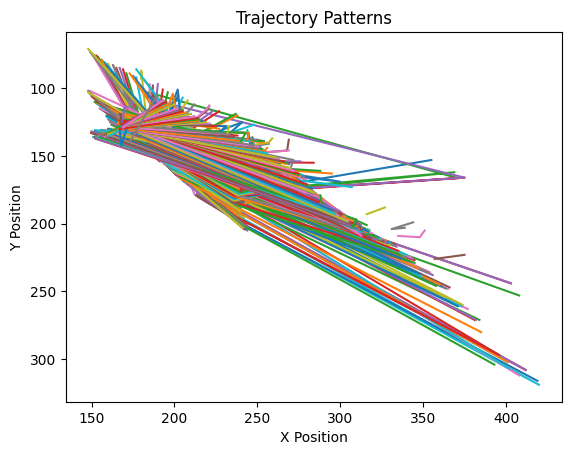

In [11]:
for pid in trajectories:

    pts = np.array(trajectories[pid])
    
    if len(pts) > 1:
        plt.plot(pts[:,0], pts[:,1])

plt.gca().invert_yaxis()

plt.title("Trajectory Patterns")
plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.show()


In [12]:
from IPython.display import Video

Video("/kaggle/working/trajectory_output.mp4", embed=True)


In [13]:
import os
os.listdir("/kaggle/working")


['Deep-OC-SORT', '__notebook__.ipynb']

In [14]:
import numpy as np

behavior = {}

for pid in trajectories:
    
    pts = np.array(trajectories[pid])
    
    if len(pts) < 2:
        continue
        
    speeds = []
    
    for i in range(1, len(pts)):
        x1, y1 = pts[i-1]
        x2, y2 = pts[i]
        
        dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        speeds.append(dist)
    
    avg_speed = np.mean(speeds)
    
    if avg_speed < 2:
        label = "Standing"
        
    elif avg_speed < 10:
        label = "Normal Walking"
        
    elif avg_speed < 25:
        label = "Fast Movement"
        
    else:
        label = "Suspicious Running"
    
    behavior[pid] = label

print("Detected Behaviour Patterns:\n")

for pid in behavior:
    print(f"Person {pid} → {behavior[pid]}")


Detected Behaviour Patterns:

Person 0 → Suspicious Running
Person 1 → Suspicious Running
Person 2 → Suspicious Running
Person 3 → Suspicious Running
Person 4 → Suspicious Running
Person 5 → Suspicious Running
Person 6 → Suspicious Running
Person 7 → Suspicious Running
Person 8 → Suspicious Running
Person 9 → Suspicious Running
Person 12 → Suspicious Running
Person 13 → Suspicious Running
Person 14 → Suspicious Running
Person 15 → Suspicious Running
Person 16 → Suspicious Running
Person 18 → Fast Movement
Person 21 → Normal Walking
Person 22 → Fast Movement
Person 24 → Fast Movement
Person 27 → Suspicious Running
Person 28 → Suspicious Running
Person 29 → Suspicious Running
Person 30 → Suspicious Running
Person 31 → Suspicious Running
Person 32 → Suspicious Running
Person 34 → Suspicious Running
Person 35 → Suspicious Running
Person 36 → Suspicious Running
Person 37 → Suspicious Running
Person 38 → Suspicious Running
Person 40 → Suspicious Running
Person 41 → Suspicious Running
Person 

In [15]:
import pandas as pd

data = []

for pid in behavior:
    data.append([pid, behavior[pid]])

df = pd.DataFrame(data, columns=["Person_ID", "Behaviour"])

df.to_csv("/kaggle/working/behavior_analysis.csv", index=False)

print("Behaviour CSV saved!")


Behaviour CSV saved!


In [16]:
import os
os.listdir("/kaggle/working")


['Deep-OC-SORT', '__notebook__.ipynb', 'behavior_analysis.csv']